# Asthma Prediction Model

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data downloaded from https://datashare.ed.ac.uk/items/8478e384-fd1b-4a37-9555-0c6e1218e90b
path = "../model/data/raw" 
files = [
    "peakflow", "smartinhaler", "smartwatch1", "smartwatch2", "smartwatch3",
    "dailyquestionnaire", "weeklyquestionnaire", "endquestionnaire", "environment", "patient_info"
]

dfs = {f: pd.read_csv(f"{path}/anonym_aamos00_{f}.csv") for f in files}

# 1. EDA & Data Preprocessing per Table

**Note:** We've chosen to retain most missing values, under the assumption that users might frequently forget to input certain data points. Further imputation strategies will be considered if necessary.

## Peakflow

In [3]:
df = dfs['peakflow']

print(f"--- PEAKFLOW HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in PEAKFLOW ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- PEAKFLOW SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- PEAKFLOW HEAD ---


,user_key,date,hour,pef_max,pefs,morning
0,113,1,7,469,469|99|144,True
1,113,1,15,310,310|174|175,False
2,113,3,13,290,249|290|207,True
3,113,40,16,557,71|557|525,False
4,190,6,7,333,333|307|150,True




--- Missing Values in PEAKFLOW ---
      Missing Count  Missing Percentage
pefs            173           11.411609


--- PEAKFLOW SUMMARY STATISTICS ---


,user_key,date,hour,pef_max,pefs,morning
count,1516.000000,1516.000000,1516.000000,1516.000000,1343,1516
unique,NaN,NaN,NaN,NaN,1342,2
top,NaN,NaN,NaN,NaN,364|372|342,True
freq,NaN,NaN,NaN,NaN,2,822
mean,480.914908,69.709103,13.246702,397.932058,NaN,NaN
std,245.093118,50.787506,6.313678,93.872577,NaN,NaN
min,113.000000,-2.000000,0.000000,120.000000,NaN,NaN
25%,294.000000,26.000000,7.000000,318.000000,NaN,NaN
50%,447.000000,59.000000,11.000000,399.000000,NaN,NaN
75%,702.000000,109.000000,20.000000,461.000000,NaN,NaN


For Peakflow data, we will utilize `pef_max` instead of `pefs`. The `pefs` column contains a significant number of missing values, and using pef_max clinically makes more sense since it correlates with the maximum amount of air a patient can breath in.

In [4]:
user_missing_values = dfs['peakflow'][dfs['peakflow']['pefs'].isnull()].user_key.unique()
filtered_pefs = dfs['peakflow'][['user_key', 'pefs']][dfs['peakflow']['user_key'].isin(user_missing_values)]
filtered_pefs['pefs'].isna().groupby(dfs['peakflow']['user_key']).value_counts()


user_key  pefs 
473       False     88
          True      52
625       False      5
          True       3
702       True     118
          False     64
Name: count, dtype: int64

In [5]:
dfs['peakflow']['pefs'].head(10)

,pefs
0,469|99|144
1,310|174|175
2,249|290|207
3,71|557|525
4,333|307|150
5,294|267|278
6,269|255|256
7,262|273|270
8,329|307|324
9,292|266|260


For users exhibiting missing `pefs` values, a substantial portion of these values are indeed absent. Given the wide distribution and prevalence of 'failure' entries within the `pefs` column, we will instead rely on `pef_max`, which contains no missing values, for our analysis.

## Smartinhaler

In [6]:
df = dfs['smartinhaler']

print(f"--- SMARTINHALER HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in SMARTINHALER ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- SMARTINHALER SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- SMARTINHALER HEAD ---


,user_key,date,hour,name
0,113,0,15,VENTOLIN
1,113,0,15,VENTOLIN
2,113,0,15,VENTOLIN
3,113,0,15,VENTOLIN
4,113,0,15,VENTOLIN




--- Missing Values in SMARTINHALER ---
No missing values.


--- SMARTINHALER SUMMARY STATISTICS ---


,user_key,date,hour,name
count,2904.000000,2904.000000,2904.000000,2904
unique,NaN,NaN,NaN,4
top,NaN,NaN,NaN,VENTOLIN
freq,NaN,NaN,NaN,1852
mean,532.773760,69.076446,13.369490,NaN
std,295.286198,53.333614,6.203866,NaN
min,113.000000,-5.000000,0.000000,NaN
25%,294.000000,23.000000,8.000000,NaN
50%,447.000000,56.000000,13.000000,NaN
75%,939.000000,111.000000,19.000000,NaN


## Smartwatch

### Overview

In [7]:
df = dfs['smartwatch1']

print(f"--- SMARTWATCH1 HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in SMARTWATCH1 ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- SMARTWATCH1 SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- SMARTWATCH1 HEAD ---


,user_key,date,time,activity_type,intensity,steps,hr
0,113,0,09:35:00,80,31,0,NaN
1,113,0,09:36:00,96,6,0,72.0
2,113,0,09:37:00,80,0,0,73.0
3,113,0,09:38:00,80,13,0,74.0
4,113,0,09:39:00,90,20,0,75.0




--- Missing Values in SMARTWATCH1 ---
    Missing Count  Missing Percentage
hr         197760              19.776


--- SMARTWATCH1 SUMMARY STATISTICS ---


,user_key,date,time,activity_type,intensity,steps,hr
count,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,802240.000000
unique,NaN,NaN,1440,NaN,NaN,NaN,NaN
top,NaN,NaN,17:20:00,NaN,NaN,NaN,NaN
freq,NaN,NaN,703,NaN,NaN,NaN,NaN
mean,260.244679,77.678519,NaN,86.428345,26.604138,4.756677,83.772912
std,108.929311,52.320920,NaN,34.104460,30.601191,17.891647,15.440729
min,113.000000,-1.000000,NaN,1.000000,0.000000,0.000000,1.000000
25%,190.000000,32.000000,NaN,80.000000,0.000000,0.000000,72.000000
50%,294.000000,70.000000,NaN,96.000000,20.000000,0.000000,81.000000
75%,343.000000,120.000000,NaN,112.000000,44.000000,0.000000,94.000000


In [8]:
df = dfs['smartwatch2']

print(f"--- SMARTWATCH2 HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in SMARTWATCH2 ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- SMARTWATCH2 SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- SMARTWATCH2 HEAD ---


,user_key,date,time,activity_type,intensity,steps,hr
0,447,70,06:24:00,80,70,0,91.0
1,447,70,06:25:00,80,56,0,91.0
2,447,70,06:26:00,17,72,46,90.0
3,447,70,06:27:00,16,60,0,90.0
4,447,70,06:28:00,96,66,0,89.0




--- Missing Values in SMARTWATCH2 ---
    Missing Count  Missing Percentage
hr         315687             31.5687


--- SMARTWATCH2 SUMMARY STATISTICS ---


,user_key,date,time,activity_type,intensity,steps,hr
count,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,684313.000000
unique,NaN,NaN,1440,NaN,NaN,NaN,NaN
top,NaN,NaN,16:08:00,NaN,NaN,NaN,NaN
freq,NaN,NaN,701,NaN,NaN,NaN,NaN
mean,695.143241,58.596719,NaN,86.083864,25.972037,4.350852,80.567502
std,147.152541,45.837634,NaN,36.348261,32.853031,16.504833,17.905120
min,447.000000,0.000000,NaN,1.000000,0.000000,0.000000,1.000000
25%,514.000000,23.000000,NaN,80.000000,0.000000,0.000000,68.000000
50%,702.000000,47.000000,NaN,96.000000,15.000000,0.000000,79.000000
75%,808.000000,85.000000,NaN,112.000000,44.000000,0.000000,92.000000


In [9]:
df = dfs['smartwatch3']

print(f"--- SMARTWATCH3 HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in SMARTWATCH3 ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- SMARTWATCH3 SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- SMARTWATCH3 HEAD ---


,user_key,date,time,activity_type,intensity,steps,hr
0,939,99,13:21:00,80,17,0,94.0
1,939,99,13:22:00,80,20,0,97.0
2,939,99,13:23:00,80,3,0,96.0
3,939,99,13:24:00,80,48,0,95.0
4,939,99,13:25:00,17,58,38,95.0




--- Missing Values in SMARTWATCH3 ---
    Missing Count  Missing Percentage
hr          18281           17.952646


--- SMARTWATCH3 SUMMARY STATISTICS ---


,user_key,date,time,activity_type,intensity,steps,hr
count,101829.0,101829.000000,101829,101829.000000,101829.000000,101829.000000,83548.000000
unique,NaN,NaN,1440,NaN,NaN,NaN,NaN
top,NaN,NaN,05:23:00,NaN,NaN,NaN,NaN
freq,NaN,NaN,72,NaN,NaN,NaN,NaN
mean,939.0,136.805733,NaN,85.577684,32.398109,8.047108,78.041150
std,0.0,22.699869,NaN,33.207252,43.525090,28.639688,23.647143
min,939.0,99.000000,NaN,1.000000,0.000000,0.000000,1.000000
25%,939.0,118.000000,NaN,80.000000,0.000000,0.000000,60.000000
50%,939.0,135.000000,NaN,96.000000,20.000000,0.000000,74.000000
75%,939.0,154.000000,NaN,112.000000,50.000000,0.000000,90.000000


Note: `hr` denotes the average heart rate, measured in Beats Per Minute (BPM), over a 1-minute interval.

### Feature Engineering


In [10]:
dfs['smartwatch'] = pd.concat([dfs['smartwatch1'], dfs['smartwatch2'], dfs['smartwatch3']])
dfs['smartwatch'].groupby(['user_key', 'date'])['hr'].count()

user_key  date
113       0        732
          1       1188
          2       1150
          3       1271
          4       1205
                  ... 
939       174     1213
          175     1215
          176     1223
          177     1248
          178      209
Name: hr, Length: 1567, dtype: int64

In [11]:
dfs['smartwatch'].head(100)

,user_key,date,time,activity_type,intensity,steps,hr
0,113,0,09:35:00,80,31,0,NaN
1,113,0,09:36:00,96,6,0,72.0
2,113,0,09:37:00,80,0,0,73.0
3,113,0,09:38:00,80,13,0,74.0
4,113,0,09:39:00,90,20,0,75.0
...,...,...,...,...,...,...,...
95,113,0,11:10:00,1,82,71,104.0
96,113,0,11:11:00,1,67,33,106.0
97,113,0,11:12:00,1,79,19,106.0
98,113,0,11:13:00,1,69,27,104.0


In [12]:
smartwatch = dfs['smartwatch']
smartwatch["is_running"] = smartwatch["activity_type"].isin([66,98,82])
smartwatch["is_sleep"] = smartwatch["activity_type"].isin([106,112,121,122,123])
smartwatch["is_sedentary"] = smartwatch["activity_type"].isin([80,89,90,91,92,96])

activity_day_summary = smartwatch\
.groupby(["user_key","date"])\
.agg(
    running_minutes=("is_running","sum"),
    sleep_minutes=("is_sleep","sum"),
    sedentary_minutes=("is_sedentary","sum"),
    total_steps=("steps","sum"),
    avg_hr=("hr","mean")
)


activity_day_summary[activity_day_summary['avg_hr'].isnull()]

running_minutes  sleep_minutes  sedentary_minutes  total_steps  \
user_key date                                                                   
294      -1                  0              2                  0            0   
454       8                  0              0                  0            0   
473       56                 0              0                  0            0   
514       66                 0              0                  0            0   
          182                0              0                  0            0   
          183                0              1                  0            0   
625       17                 0              0                  0            0   
          19                 0              0                  0            0   
          20                 0              0                  0            0   
          26                 0              0                  0            0   
701       78                 0              0                  0            0   
702       148                0              0                  0            0   
          154                0              0                  0            0   
          155                0              0                  0            0   
764       20                 0              0                  0            0   
          21                 0              0                  0            0   
          22                 0              0                  0            0   
          23                 0              0                  0            0   
          28                 0              0                  0            0   
          29                 0              0                  0            0   
          50                 0              0                  0            0   
808       39                 0              0                  0            0   
          40                 0              0                  0            0   
          43                 0              1                  0            0   
          66                 0              0                  0            0   
          67                 0              0                  0            0   
          68                 0              0                  0            0   
          69                 0              0                  0            0   
          70                 0              0                  0            0   
          71                 0              0                  0            0   
          72                 0              0                  0            0   

               avg_hr  
user_key date          
294      -1       NaN  
454       8       NaN  
473       56      NaN  
514       66      NaN  
          182     NaN  
          183     NaN  
625       17      NaN  
          19      NaN  
          20      NaN  
          26      NaN  
701       78      NaN  
702       148     NaN  
          154     NaN  
          155     NaN  
764       20      NaN  
          21      NaN  
          22      NaN  
          23      NaN  
          28      NaN  
          29      NaN  
          50      NaN  
808       39      NaN  
          40      NaN  
          43      NaN  
          66      NaN  
          67      NaN  
          68      NaN  
          69      NaN  
          70      NaN  
          71      NaN  
          72      NaN

In [13]:
activity_day_summary.head()

running_minutes  sleep_minutes  sedentary_minutes  total_steps  \
user_key date                                                                   
113      0                   0            400                365         3035   
         1                   0            582                509        19591   
         2                   0            475                641        17615   
         3                   0            507                577        20264   
         4                   0            535                603         9266   

                  avg_hr  
user_key date             
113      0     76.610656  
         1     83.728114  
         2     85.743478  
         3     89.924469  
         4     84.513693

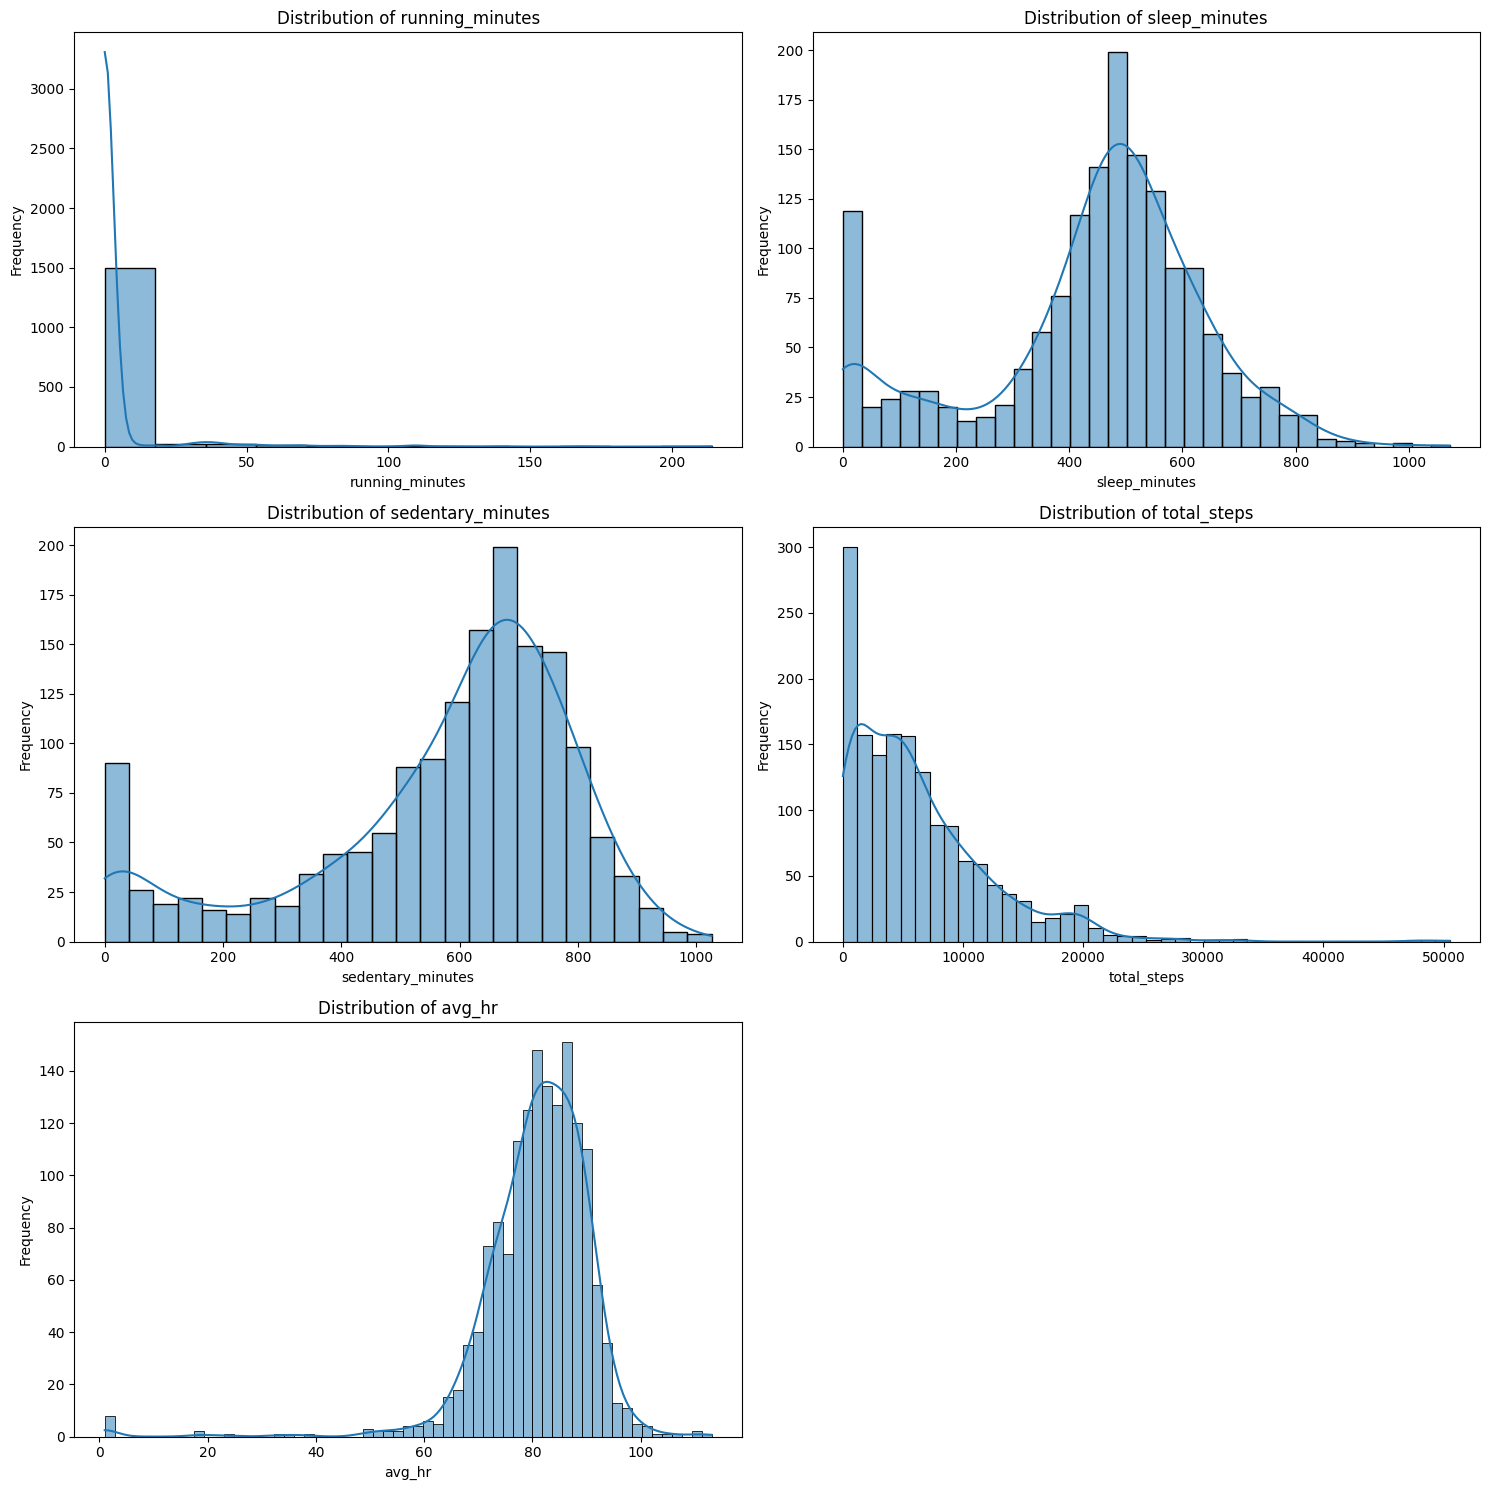

In [14]:

# Get numerical columns from activity_day_summary
numerical_cols = activity_day_summary.select_dtypes(include=['number']).columns

# Set up the figure and axes for the histograms
num_plots = len(numerical_cols)
num_rows = (num_plots + 1) // 2 # Arrange in 2 columns
fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
axes = axes.flatten() # Flatten the array for easy iteration

# Loop through each numerical column and create a histogram
for i, col in enumerate(numerical_cols):
    sns.histplot(activity_day_summary[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Questionnaires

## Daily Questionnaire: TARGET

In [15]:
df = dfs['dailyquestionnaire']

print(f"--- DAILYQUESTIONNAIRE HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in DAILYQUESTIONNAIRE ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- DAILYQUESTIONNAIRE SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- DAILYQUESTIONNAIRE HEAD ---


,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers
0,113,0,True,True,False,2,5,"5,9"
1,113,1,False,False,False,2,3,"5,9"
2,113,2,False,True,False,2,5,"5,9"
3,113,3,False,False,False,2,1,"5,12"
4,113,4,False,True,False,2,3,"5,9"




--- Missing Values in DAILYQUESTIONNAIRE ---
                      Missing Count  Missing Percentage
daily_triggers                   11            0.694883
daily_limit_activity              1            0.063171


--- DAILYQUESTIONNAIRE SUMMARY STATISTICS ---


,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers
count,1583.000000,1583.000000,1583,1583,1582,1583.000000,1583.000000,1572
unique,NaN,NaN,2,2,2,NaN,NaN,196
top,NaN,NaN,False,True,False,NaN,NaN,1
freq,NaN,NaN,1258,1220,971,NaN,NaN,364
mean,489.155401,73.435881,NaN,NaN,NaN,2.119394,1.651927,NaN
std,262.781124,52.614244,NaN,NaN,NaN,0.478643,2.183899,NaN
min,113.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,NaN
25%,294.000000,27.000000,NaN,NaN,NaN,2.000000,0.000000,NaN
50%,447.000000,64.000000,NaN,NaN,NaN,2.000000,1.000000,NaN
75%,702.000000,116.000000,NaN,NaN,NaN,2.000000,3.000000,NaN


In [16]:
df = dfs['dailyquestionnaire']
df['target'] = (df['daily_night_symp'] | df['daily_day_symp'] | df['daily_limit_activity'] | (df['daily_prev_inhaler']==4) | (df['daily_relief_inhaler'] > 0))
df['target'].value_counts()

,count
target,
True,1316
False,267


/tmp/ipykernel_2922/2377283503.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_2922/2377283503.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_2922/2377283503.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_2922/2377283503.py:28: FutureWarning: 

Passing `palette` without assi

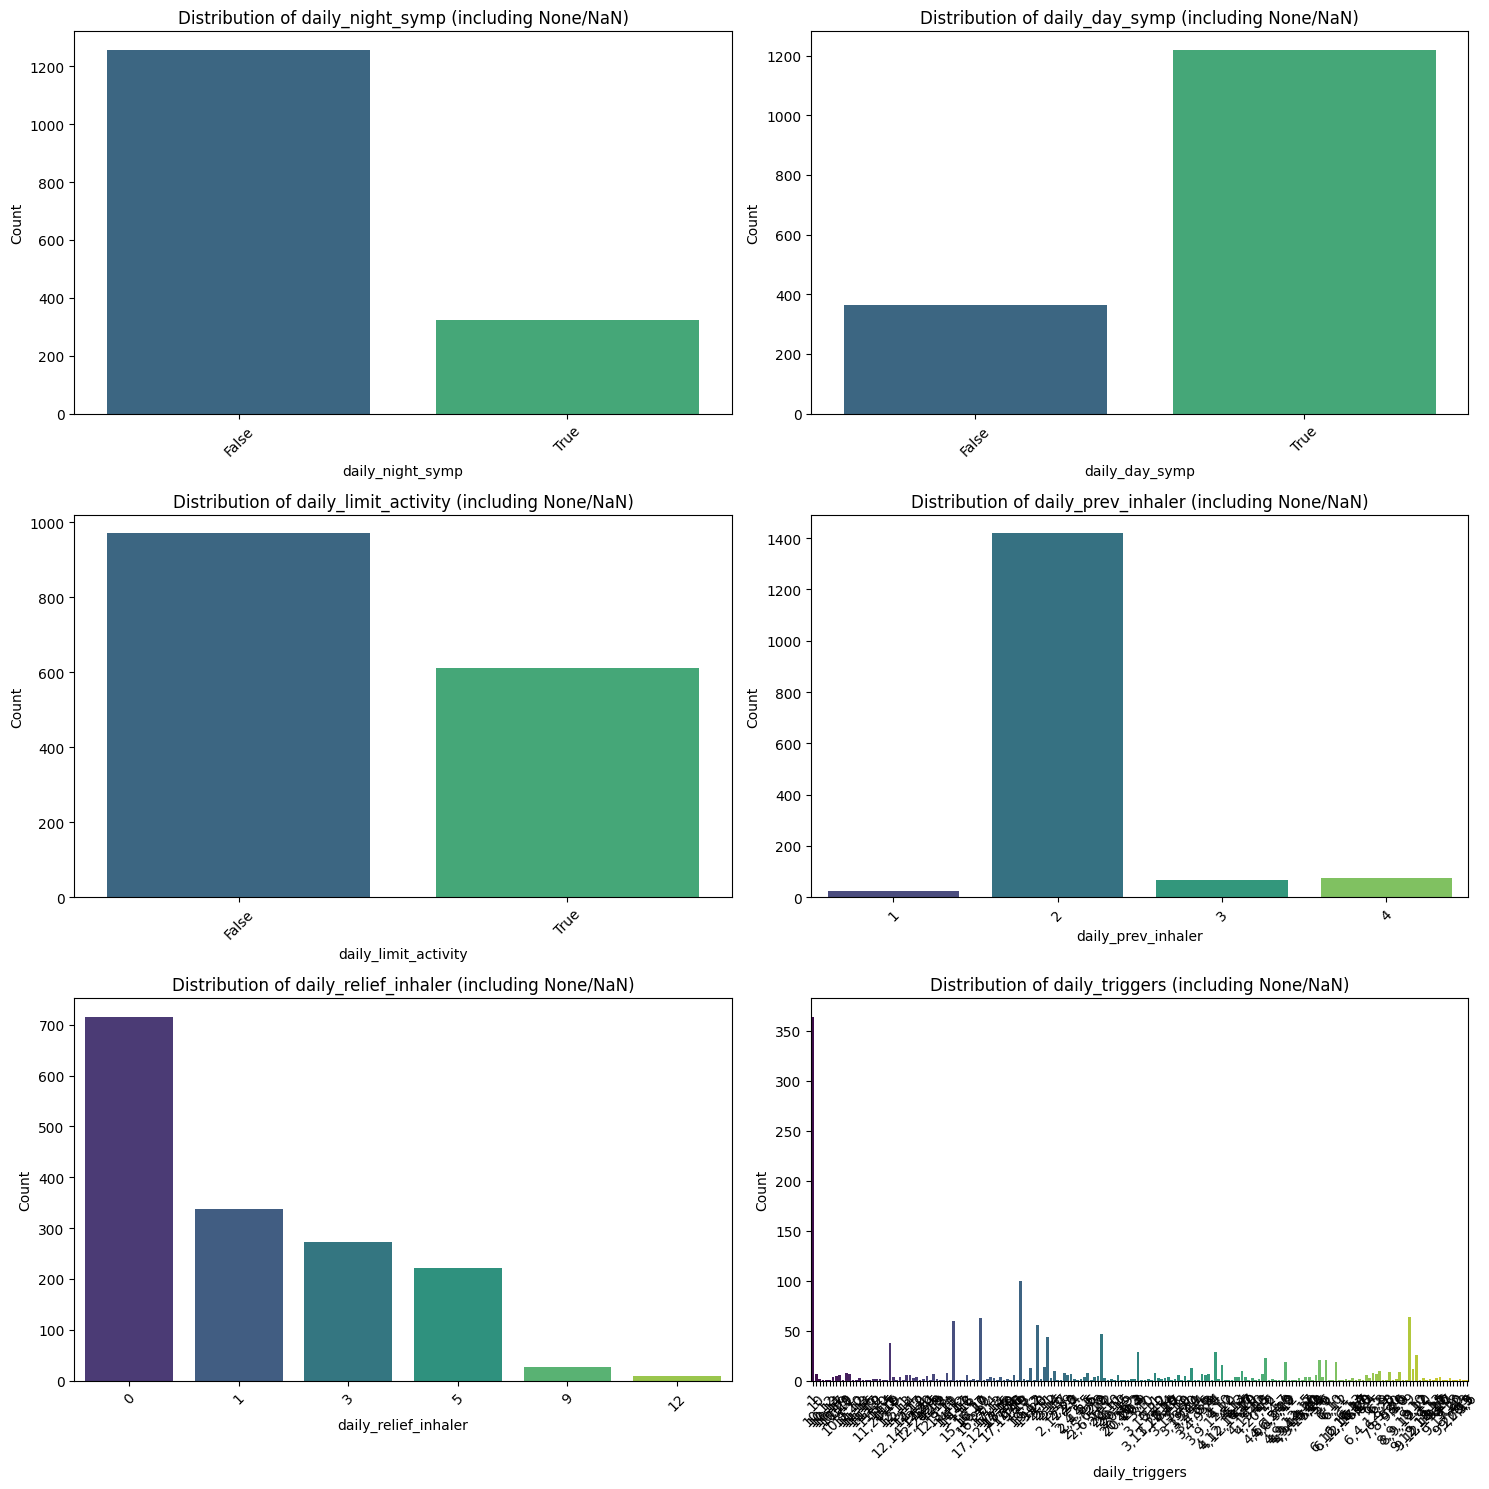

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df = dfs['dailyquestionnaire']

# Columns to analyze for daily questionnaire, excluding identifiers and the already derived 'target'
columns_to_plot = [
    'daily_night_symp', 'daily_day_symp', 'daily_limit_activity',
    'daily_prev_inhaler', 'daily_relief_inhaler', 'daily_triggers'
]

# Set up the figure and axes for the bar charts
num_plots = len(columns_to_plot)
num_rows = (num_plots + 1) // 2 # Arrange in 2 columns
fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
axes = axes.flatten() # Flatten the array for easy iteration

# Loop through each selected column and create a bar chart of value counts
for i, col in enumerate(columns_to_plot):
    # For boolean columns, convert to string to treat True/False/NaN as distinct categories
    if df[col].dtype == 'bool':
        plot_data = df[col].astype(str).value_counts(dropna=False).sort_index()
    else:
        # For numerical/categorical columns, get value counts including NaN
        plot_data = df[col].value_counts(dropna=False).sort_index()

    # Create a bar plot
    sns.barplot(x=plot_data.index, y=plot_data.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col} (including None/NaN)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # Rotate labels if they overlap

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NOTE: We initially considered treating the value '5' in `daily_prev_inhaler` as a missing value, as it signifies "I'm not sure." However, upon inspection, the value '5' does not appear in the dataset, rendering special handling unnecessary.

## Other Questionnaires: Ignored for Now

In [18]:
df = dfs['weeklyquestionnaire']

print(f"--- WEEKLYQUESTIONNAIRE HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in WEEKLYQUESTIONNAIRE ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- WEEKLYQUESTIONNAIRE SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- WEEKLYQUESTIONNAIRE HEAD ---


,user_key,date,weekly_night_symp,weekly_day_symp,weekly_limit_activity,weekly_short_breath,weekly_wheeze,weekly_relief_inhaler,weekly_doc,weekly_hospital,weekly_er,weekly_oral
0,113,1,2.0,3.0,1.0,2,2,3,-4,0,0,2.0
1,113,7,2.0,3.0,2.0,2,2,2,-5,0,0,2.0
2,113,14,5.0,5.0,5.0,4,4,5,"-1,-3",0,-2,3.0
3,113,22,4.0,5.0,4.0,4,2,4,-3,0,0,3.0
4,113,28,3.0,3.0,3.0,3,2,3,0,0,0,3.0




--- Missing Values in WEEKLYQUESTIONNAIRE ---
                       Missing Count  Missing Percentage
weekly_night_symp                176           54.320988
weekly_limit_activity            115           35.493827
weekly_day_symp                   33           10.185185
weekly_doc                         1            0.308642
weekly_oral                        1            0.308642


--- WEEKLYQUESTIONNAIRE SUMMARY STATISTICS ---


,user_key,date,weekly_night_symp,weekly_day_symp,weekly_limit_activity,weekly_short_breath,weekly_wheeze,weekly_relief_inhaler,weekly_doc,weekly_hospital,weekly_er,weekly_oral
count,324.000000,324.000000,148.000000,291.000000,209.000000,324.000000,324.000000,324.000000,323,324.000000,324.000000,323.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280,NaN,NaN,NaN
mean,522.941358,74.716049,2.568919,5.364261,3.913876,2.398148,1.851852,2.543210,NaN,-0.064815,-0.067901,1.386997
std,254.508997,54.179208,1.737417,2.115125,2.221453,0.930460,0.867167,1.457759,NaN,0.549807,0.552243,0.710667
min,113.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,-7.000000,-7.000000,1.000000
25%,294.000000,28.000000,1.000000,4.000000,2.000000,2.000000,1.000000,1.750000,NaN,0.000000,0.000000,1.000000
50%,514.000000,67.000000,2.000000,7.000000,3.000000,2.000000,2.000000,2.000000,NaN,0.000000,0.000000,1.000000
75%,702.000000,119.000000,3.000000,7.000000,6.000000,3.000000,2.000000,3.000000,NaN,0.000000,0.000000,2.000000


In [19]:
df = dfs['endquestionnaire']

print(f"--- ENDQUESTIONNAIRE HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in ENDQUESTIONNAIRE ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- ENDQUESTIONNAIRE SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- ENDQUESTIONNAIRE HEAD ---


,user_key,completion_date,i_think_that_i_would_like_to_use_this_system_frequently,i_found_the_system_unnecessarily_complex,i_thought_the_system_was_easy_to_use,i_think_that_i_would_need_the_support_of_a_technical_person_to_be_able_to_use_this_system,i_found_the_various_functions_in_this_system_were_well_integrated,i_thought_there_was_too_much_inconsistency_in_this_system,i_would_imagine_that_most_people_would_learn_to_use_this_system_very_quickly,i_found_the_system_very_cumbersome_to_use,...,awareness_a_this_study_has_increased_my_awareness_of_the_importance_of_addressing_the_health_behaviour,knowledge_a_this_study_has_increased_my_knowledge_understanding_of_the_health_behaviour,attitudes_a_the_study_has_changed_my_attitudes_toward_improving_this_health_behaviour,intention_to_change_a_the_study_has_increased_my_intentions_motivation_to_address_this_health_behaviour,help_seeking_a_this_app_would_encourage_me_to_seek_further_help_to_address_the_health_behaviour_if_i_needed_it,behaviour_change_a_use_of_this_app_will_increase_decrease_the_health_behaviour,i_would_pay_for_the_find_air_one_rrp_59_00_eur_per_year,i_would_pay_for_the_smart_asthma_smart_peak_flow_meter_rrp_59_60_gbp,i_would_pay_for_the_mi_band_3_smartwatch_rrp_25_00_gbp,i_had_received_training_in_taking_peak_flow_measurements_with_a_peak_flow_meter_from_a_healthcare_professional_e_g_asthma_doctor_nurse_pharmacist_etc_prior_to_joining_this_study
0,113,178,(4) Agree,(3) Neither agree nor disagree,(5) Strongly agree,(1) Strongly disagree,(5) Strongly agree,(2) Disagree,(5) Strongly agree,(2) Disagree,...,(5) Strongly agree,(3) Neither agree nor disagree,(4) Agree,(4) Agree,(5) Strongly agree,(4) Agree,(3) Neither agree nor disagree,(1) Strongly disagree,(2) Disagree,Yes
1,190,166,(4) Agree,(2) Disagree,(5) Strongly agree,(2) Disagree,(4) Agree,(2) Disagree,(4) Agree,(2) Disagree,...,(4) Agree,(4) Agree,(4) Agree,(4) Agree,(4) Agree,(4) Agree,(2) Disagree,(4) Agree,(4) Agree,Yes
2,294,179,(4) Agree,(2) Disagree,(4) Agree,(1) Strongly disagree,(4) Agree,(2) Disagree,(5) Strongly agree,(2) Disagree,...,(5) Strongly agree,(5) Strongly agree,(5) Strongly agree,(4) Agree,(5) Strongly agree,(5) Strongly agree,(2) Disagree,(2) Disagree,(4) Agree,Yes
3,343,176,(2) Disagree,(3) Neither agree nor disagree,(2) Disagree,(4) Agree,(3) Neither agree nor disagree,(2) Disagree,(4) Agree,(3) Neither agree nor disagree,...,(3) Neither agree nor disagree,(2) Disagree,(2) Disagree,(2) Disagree,(3) Neither agree nor disagree,(2) Disagree,(1) Strongly disagree,(1) Strongly disagree,(1) Strongly disagree,Yes
4,447,143,(2) Disagree,(3) Neither agree nor disagree,(2) Disagree,(2) Disagree,(3) Neither agree nor disagree,(5) Strongly agree,(2) Disagree,(2) Disagree,...,(4) Agree,(2) Disagree,(2) Disagree,(2) Disagree,(4) Agree,(2) Disagree,(2) Disagree,(2) Disagree,(1) Strongly disagree,Yes




--- Missing Values in ENDQUESTIONNAIRE ---
                                                    Missing Count  \
i_should_be_able_to_connect_with_my_healthcare_...              1   
graphics_there_were_high_quality_resolution_of_...              1   

                                                    Missing Percentage  
i_should_be_able_to_connect_with_my_healthcare_...            7.142857  
graphics_there_were_high_quality_resolution_of_...            7.142857  


--- ENDQUESTIONNAIRE SUMMARY STATISTICS ---


,user_key,completion_date,i_think_that_i_would_like_to_use_this_system_frequently,i_found_the_system_unnecessarily_complex,i_thought_the_system_was_easy_to_use,i_think_that_i_would_need_the_support_of_a_technical_person_to_be_able_to_use_this_system,i_found_the_various_functions_in_this_system_were_well_integrated,i_thought_there_was_too_much_inconsistency_in_this_system,i_would_imagine_that_most_people_would_learn_to_use_this_system_very_quickly,i_found_the_system_very_cumbersome_to_use,...,awareness_a_this_study_has_increased_my_awareness_of_the_importance_of_addressing_the_health_behaviour,knowledge_a_this_study_has_increased_my_knowledge_understanding_of_the_health_behaviour,attitudes_a_the_study_has_changed_my_attitudes_toward_improving_this_health_behaviour,intention_to_change_a_the_study_has_increased_my_intentions_motivation_to_address_this_health_behaviour,help_seeking_a_this_app_would_encourage_me_to_seek_further_help_to_address_the_health_behaviour_if_i_needed_it,behaviour_change_a_use_of_this_app_will_increase_decrease_the_health_behaviour,i_would_pay_for_the_find_air_one_rrp_59_00_eur_per_year,i_would_pay_for_the_smart_asthma_smart_peak_flow_meter_rrp_59_60_gbp,i_would_pay_for_the_mi_band_3_smartwatch_rrp_25_00_gbp,i_had_received_training_in_taking_peak_flow_measurements_with_a_peak_flow_meter_from_a_healthcare_professional_e_g_asthma_doctor_nurse_pharmacist_etc_prior_to_joining_this_study
count,14.000000,14.000000,14,14,14,14,14,14,14,14,...,14,14,14,14,14,14,14,14,14,14
unique,NaN,NaN,5,5,5,4,5,4,5,5,...,3,4,4,4,3,4,5,3,4,1
top,NaN,NaN,(4) Agree,(3) Neither agree nor disagree,(2) Disagree,(1) Strongly disagree,(4) Agree,(2) Disagree,(4) Agree,(2) Disagree,...,(3) Neither agree nor disagree,(4) Agree,(4) Agree,(4) Agree,(4) Agree,(4) Agree,(2) Disagree,(1) Strongly disagree,(1) Strongly disagree,Yes
freq,NaN,NaN,4,4,5,7,6,5,8,5,...,6,5,6,9,8,6,6,7,6,14
mean,542.357143,177.642857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,257.004821,44.105829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,113.000000,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,369.000000,167.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,493.500000,178.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,736.500000,201.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Environment Data

In [20]:
df = dfs['environment']

print(f"--- ENVIRONMENT HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in ENVIRONMENT ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- ENVIRONMENT SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- ENVIRONMENT HEAD ---


,user_key,date,temperature,temperature_min,temperature_max,pressure,humidity,wind_speed,wind_deg,aqi,...,no,no2,o3,so2,pm2_5,pm10,nh3,grass_pollen,tree_pollen,weed_pollen
0,113,1,15.91,14.21,17.20,1015,88,0.89,53,1.0,...,0.19,8.65,47.92,2.89,7.55,8.51,0.82,High,Low,Moderate
1,113,2,16.67,14.92,18.71,1014,96,0.45,24,1.0,...,0.55,15.94,28.97,6.68,3.97,4.82,0.29,High,Moderate,High
2,113,3,17.07,15.00,18.31,1015,79,1.34,17,1.0,...,0.49,8.14,56.51,3.04,3.93,7.39,0.65,High,Moderate,High
3,113,4,18.08,15.22,20.13,1017,78,0.89,16,1.0,...,0.19,2.29,79.39,0.78,2.91,4.09,1.20,High,Moderate,Moderate
4,113,5,20.82,17.81,22.86,1015,86,1.79,135,1.0,...,0.11,4.84,78.68,1.85,8.35,9.05,1.63,High,Low,Moderate




--- Missing Values in ENVIRONMENT ---
              Missing Count  Missing Percentage
weed_pollen              50            3.017502
grass_pollen             50            3.017502
tree_pollen              50            3.017502
aqi                       5            0.301750
no2                       5            0.301750
no                        5            0.301750
co                        5            0.301750
o3                        5            0.301750
pm10                      5            0.301750
pm2_5                     5            0.301750
so2                       5            0.301750
nh3                       5            0.301750


--- ENVIRONMENT SUMMARY STATISTICS ---


,user_key,date,temperature,temperature_min,temperature_max,pressure,humidity,wind_speed,wind_deg,aqi,...,no,no2,o3,so2,pm2_5,pm10,nh3,grass_pollen,tree_pollen,weed_pollen
count,1657.000000,1657.000000,1657.000000,1657.000000,1657.000000,1657.000000,1657.000000,1657.000000,1657.000000,1652.00000,...,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1607,1607,1607
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Low,Low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1164,1479,552
mean,493.492456,74.311406,12.513482,10.959113,14.072661,1015.105009,83.251056,3.393905,192.675317,1.26937,...,1.009340,8.522464,51.550036,2.204455,5.081265,6.757942,1.278123,NaN,NaN,NaN
std,257.468492,53.560788,6.125199,6.126956,6.219410,10.772677,11.528047,2.706920,102.070135,0.61435,...,6.171241,9.083929,23.209088,2.427661,6.151962,7.231278,1.480510,NaN,NaN,NaN
min,113.000000,0.000000,-2.740000,-6.130000,-0.880000,972.000000,29.000000,0.000000,0.000000,1.00000,...,0.000000,0.120000,0.000000,0.030000,0.500000,0.540000,0.000000,NaN,NaN,NaN
25%,294.000000,26.000000,8.190000,6.550000,9.640000,1009.000000,78.000000,1.340000,129.000000,1.00000,...,0.000000,2.960000,37.190000,0.770000,1.690000,2.530000,0.480000,NaN,NaN,NaN
50%,473.000000,68.000000,12.880000,11.500000,14.200000,1016.000000,86.000000,2.890000,214.000000,1.00000,...,0.060000,5.570000,52.930000,1.380000,3.010000,4.565000,0.910000,NaN,NaN,NaN
75%,702.000000,118.000000,16.690000,15.220000,18.050000,1022.000000,92.000000,4.630000,267.000000,1.00000,...,0.380000,10.370000,67.230000,2.740000,5.882500,8.370000,1.620000,NaN,NaN,NaN


## Patient Info Data

In [21]:
df = dfs['patient_info']

print(f"--- PATIENT_INFO HEAD ---")
display(df.head())
print("\n" + "="*50 + "\n")

print(f"--- Missing Values in PATIENT_INFO ---")
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts * 100 / len(df))

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_info.empty:
    print(missing_info)
else:
    print("No missing values.")

print("\n" + "="*50 + "\n")

print(f"--- PATIENT_INFO SUMMARY STATISTICS ---")
display(df.describe(include='all'))
print("\n" + "="*50 + "\n")

--- PATIENT_INFO HEAD ---


,user_key,sex,age_range,bmi_range,age_diagnosed_range,max_pef_expected,smoker,pack_years,race,severity,...,position_start_date,pef_start_date,inhaler_start_date,daily_end_date,weekly_end_date,miband_end_date,position_end_date,pef_end_date,inhaler_end_date,phase2_end
0,113,female,30-39yo,Obesity,7-11yo,485,Never (<100 cigarettes in lifetime),0.00,White,Severe,...,1,1.0,0.0,183,183,183.0,183,40.0,177.0,183
1,190,male,50+yo,Pre-obesity,19+yo,575,Previous,18.75,White,Severe,...,1,6.0,1.0,183,182,148.0,183,183.0,19.0,183
2,217,female,30-39yo,Obesity,19+yo,495,Previous,6.30,White,Moderate,...,0,0.0,1.0,1,0,1.0,1,0.0,1.0,1
3,278,female,18-29yo,Pre-obesity,12-18yo,495,Previous,1.20,White,Moderate,...,0,NaN,-20.0,15,15,15.0,13,NaN,106.0,106
4,294,female,50+yo,Obesity,0-6yo,455,Never (<100 cigarettes in lifetime),0.00,White,Moderate,...,0,0.0,-5.0,183,182,183.0,183,183.0,184.0,184




--- Missing Values in PATIENT_INFO ---
                     Missing Count  Missing Percentage
pef_start_date                   6           27.272727
pef_end_date                     6           27.272727
inhaler_start_date               5           22.727273
inhaler_end_date                 5           22.727273
miband_start_date                2            9.090909
miband_end_date                  2            9.090909
age_diagnosed_range              1            4.545455
pef_best                         1            4.545455
n_inhalers                       1            4.545455


--- PATIENT_INFO SUMMARY STATISTICS ---


,user_key,sex,age_range,bmi_range,age_diagnosed_range,max_pef_expected,smoker,pack_years,race,severity,...,position_start_date,pef_start_date,inhaler_start_date,daily_end_date,weekly_end_date,miband_end_date,position_end_date,pef_end_date,inhaler_end_date,phase2_end
count,22.000000,22,22,22,21,22.000000,22,22.000000,22,22,...,22.000000,16.000000,17.000000,22.000000,22.000000,20.000000,22.000000,16.000000,17.000000,22.000000
unique,NaN,2,4,3,4,NaN,2,NaN,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,female,30-39yo,Obesity,0-6yo,NaN,Never (<100 cigarettes in lifetime),NaN,White,Moderate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,17,9,9,9,NaN,17,NaN,21,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,531.000000,NaN,NaN,NaN,NaN,511.818182,NaN,1.965909,NaN,NaN,...,0.363636,4.937500,-1.411765,110.863636,107.136364,94.800000,111.272727,105.625000,110.058824,123.318182
std,248.333493,NaN,NaN,NaN,NaN,58.626044,NaN,5.055252,NaN,NaN,...,0.726731,11.851688,5.172751,73.814630,75.806329,72.488547,74.162744,68.593367,73.897286,66.491236
min,113.000000,NaN,NaN,NaN,NaN,455.000000,NaN,0.000000,NaN,NaN,...,0.000000,-2.000000,-20.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,331.750000,NaN,NaN,NaN,NaN,475.000000,NaN,0.000000,NaN,NaN,...,0.000000,0.000000,-1.000000,37.250000,31.250000,30.750000,37.250000,47.500000,38.000000,62.500000
50%,493.500000,NaN,NaN,NaN,NaN,492.500000,NaN,0.000000,NaN,NaN,...,0.000000,0.500000,0.000000,137.500000,131.000000,76.000000,137.500000,87.500000,106.000000,151.000000
75%,736.500000,NaN,NaN,NaN,NaN,503.750000,NaN,0.000000,NaN,NaN,...,0.750000,1.000000,0.000000,182.000000,182.000000,179.000000,182.750000,182.250000,184.000000,183.750000


# 2. Feature Engineering

<Axes: xlabel='symptom_score', ylabel='Count'>

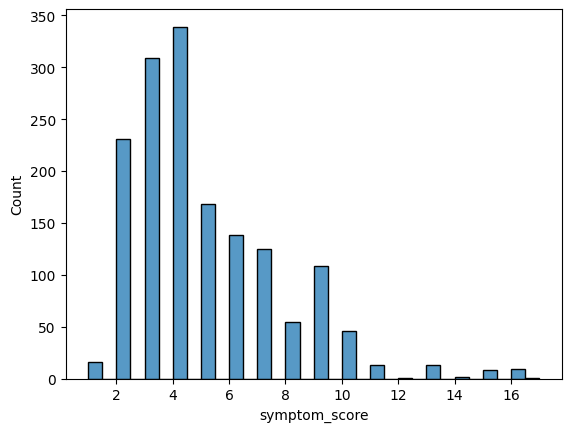

In [22]:
daily = dfs['dailyquestionnaire']
daily.loc[daily['daily_limit_activity'].isna(),'daily_limit_activity']=False #Fill this with False. Only 1 row and necessary for y value
daily['symptom_score'] = daily['daily_night_symp'] + daily['daily_day_symp'] + daily['daily_limit_activity'] + daily['daily_prev_inhaler'] + daily['daily_relief_inhaler'] # Corrected symptom_score calculation
daily['symptom_score'] = daily['symptom_score'].astype(int) # Convert to integer type

# New: Create lagged symptom score and tomorrow's target
daily['symptom_score_lag1'] = daily.groupby("user_key")['symptom_score'].shift(1)
daily['target'] = daily.groupby("user_key")['symptom_score'].shift(-1)

daily["symptom_score"].value_counts(normalize=True)
sns.histplot(data=daily, x='symptom_score')

In [23]:
daily = pd.merge(daily, dfs['environment'], on=['user_key', 'date'], how='inner')
daily.head()

,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers,target,symptom_score,...,no,no2,o3,so2,pm2_5,pm10,nh3,grass_pollen,tree_pollen,weed_pollen
0,113,1,False,False,False,2,3,"5,9",8.0,5,...,0.19,8.65,47.92,2.89,7.55,8.51,0.82,High,Low,Moderate
1,113,2,False,True,False,2,5,"5,9",3.0,8,...,0.55,15.94,28.97,6.68,3.97,4.82,0.29,High,Moderate,High
2,113,3,False,False,False,2,1,"5,12",6.0,3,...,0.49,8.14,56.51,3.04,3.93,7.39,0.65,High,Moderate,High
3,113,4,False,True,False,2,3,"5,9",6.0,6,...,0.19,2.29,79.39,0.78,2.91,4.09,1.20,High,Moderate,Moderate
4,113,5,False,True,False,2,3,"9,12",6.0,6,...,0.11,4.84,78.68,1.85,8.35,9.05,1.63,High,Low,Moderate


In [24]:
# Convert categorical columns to 'category' dtype
daily['grass_pollen'] = daily['grass_pollen'].astype('category')
daily['tree_pollen'] = daily['tree_pollen'].astype('category')
daily['weed_pollen'] = daily['weed_pollen'].astype('category')

print(f"Daily rows before PEF merge: {len(daily)}")
daily = pd.merge(daily, dfs['peakflow'], on=['user_key', 'date'], how = 'left') # Changed to left join
print(f"Daily rows after PEF merge: {len(daily)}")

Daily rows before PEF merge: 1500
Daily rows after PEF merge: 1871


In [25]:
def baseline(x):
    # Ensure at least one element is selected even if 10% is less than 1
    return x.nlargest(max(1, int(len(x)*0.1))).mean()

# Calculate baseline_per_user as a Series indexed by user_key
baseline_values = daily.groupby("user_key")["pef_max"].apply(baseline).reset_index()
baseline_values.rename(columns={'pef_max': 'baseline_per_user'}, inplace=True)
baseline_values.head()
# Merge the baseline_per_user values back to the daily DataFrame
daily = pd.merge(daily, baseline_values, on='user_key', how='left')
daily["pef_pct_best"] = daily["pef_max"] / daily['baseline_per_user']

daily['pef_lag1'] = daily.groupby("user_key")['pef_pct_best'].shift(1) # This is now pef_pct_best_lag1
daily["pef_pct_best_lag1"] = daily.groupby("user_key")['pef_pct_best'].shift(1) # New feature: lagged percentage of best PEF
daily["pef_change"] = (
    daily["pef_pct_best"] -
    daily["pef_pct_best_lag1"]
)

In [26]:
# daily = pd.merge(daily, activity_day_summary, on=['user_key', 'date'])
# daily['sedentary_minutes_lag'] = daily.groupby("user_key")['sedentary_minutes'].shift(1)
# daily['running_minutes_lag'] = daily.groupby("user_key")['running_minutes'].shift(1)
# daily['total_steps_lag'] = daily.groupby("user_key")['total_steps'].shift(1)
# daily['avg_hr_lag'] = daily.groupby("user_key")['avg_hr'].shift(1)
# daily

In [27]:
daily = pd.merge(daily, activity_day_summary, on=['user_key', 'date'], how='left')
daily['sedentary_minutes_lag'] = daily.groupby("user_key")['sedentary_minutes'].shift(1)
daily['running_minutes_lag'] = daily.groupby("user_key")['running_minutes'].shift(1)
daily['total_steps_lag'] = daily.groupby("user_key")['total_steps'].shift(1)
daily['avg_hr_lag'] = daily.groupby("user_key")['avg_hr'].shift(1)
daily

,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers,target,symptom_score,...,pef_change,running_minutes,sleep_minutes,sedentary_minutes,total_steps,avg_hr,sedentary_minutes_lag,running_minutes_lag,total_steps_lag,avg_hr_lag
0,113,1,False,False,False,2,3,"5,9",8.0,5,...,NaN,0.0,582.0,509.0,19591.0,83.728114,NaN,NaN,NaN,NaN
1,113,1,False,False,False,2,3,"5,9",8.0,5,...,-0.391144,0.0,582.0,509.0,19591.0,83.728114,509.0,0.0,19591.0,83.728114
2,113,2,False,True,False,2,5,"5,9",3.0,8,...,NaN,0.0,475.0,641.0,17615.0,85.743478,509.0,0.0,19591.0,83.728114
3,113,3,False,False,False,2,1,"5,12",6.0,3,...,NaN,0.0,507.0,577.0,20264.0,89.924469,641.0,0.0,17615.0,85.743478
4,113,4,False,True,False,2,3,"5,9",6.0,6,...,NaN,0.0,535.0,603.0,9266.0,84.513693,577.0,0.0,20264.0,89.924469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,939,177,False,True,True,2,1,9,3.0,5,...,NaN,0.0,371.0,925.0,5225.0,70.205128,759.0,76.0,16777.0,82.604252
1867,939,178,False,True,False,2,0,1,5.0,3,...,NaN,0.0,309.0,34.0,722.0,60.899522,925.0,0.0,5225.0,70.205128
1868,939,180,False,True,True,2,1,9,5.0,5,...,0.009732,NaN,NaN,NaN,NaN,NaN,34.0,0.0,722.0,60.899522
1869,939,181,False,True,True,2,1,9,5.0,5,...,-0.120032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Define X_cols and y_col globally for analysis cells
X_cols = ['temperature', 'temperature_min', 'temperature_max',
       'pressure', 'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no',
       'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen',
        'tree_pollen', 'weed_pollen', 'sleep_minutes', 'sedentary_minutes_lag', 'running_minutes_lag', 'total_steps_lag',
       'avg_hr_lag', 'pef_pct_best_lag1', 'pef_change', 'symptom_score_lag1'] # Updated to full feature set for Model 4
y_col = 'target'

Percentage of missing values per column in 'daily' DataFrame:
pef_change               37.573490
pef_pct_best_lag1        32.335649
avg_hr_lag               19.347942
sedentary_minutes_lag    19.080706
running_minutes_lag      19.080706
total_steps_lag          19.080706
sleep_minutes            18.599679
tree_pollen               2.939604
weed_pollen               2.939604
grass_pollen              2.939604
symptom_score_lag1        1.175842
target                    1.175842
aqi                       0.320684
o3                        0.320684
no2                       0.320684
no                        0.320684
co                        0.320684
so2                       0.320684
pm2_5                     0.320684
pm10                      0.320684
nh3                       0.320684
dtype: float64

Shape of data after dropping NaNs: (945, 48)


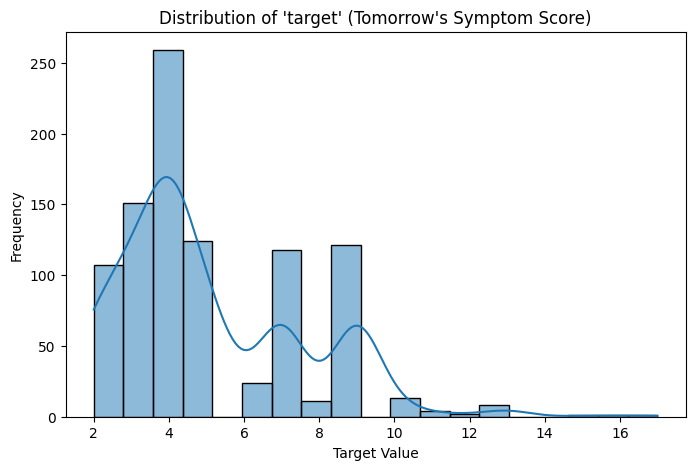

In [29]:
# Check missing values in the final dataset after all feature engineering
print("Percentage of missing values per column in 'daily' DataFrame:")
missing_percentage = daily[X_cols + [y_col]].isnull().sum() * 100 / len(daily)
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# Check shape after dropping NaNs, as done in the model cells
data_after_dropna = daily.dropna(subset=X_cols + [y_col])
print(f"\nShape of data after dropping NaNs: {data_after_dropna.shape}")

# Visualize the distribution of the 'target' variable
plt.figure(figsize=(8, 5))
sns.histplot(data_after_dropna[y_col], kde=True)
plt.title("Distribution of 'target' (Tomorrow's Symptom Score)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

<Axes: ylabel='Count'>

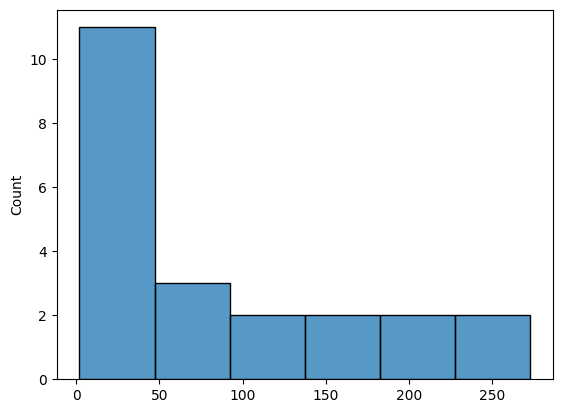

In [30]:
data_per_user = daily.groupby('user_key').size()
sns.histplot(data_per_user)

# 3. Population Model

In this section, we ensure that data from a single user does not appear in both the training and testing sets. Developing an effective population model proved challenging, partly due to the limited dataset size. More significantly, it suggests that there might not be a strong, generalized relationship between asthma flare-ups and various factors at a population level, as individual asthma triggers can vary greatly from person to person.

## Model 1: Environmental, Pollen, Lagged Symptoms

In [31]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold # Changed to GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for mean/std

X_cols = ['temperature', 'temperature_min', 'temperature_max',
       'pressure', 'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no',
       'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen',
       'tree_pollen', 'weed_pollen', 'symptom_score_lag1']
y_col = 'target' # Corrected to predict 'target' (tomorrow's symptom score)

data=daily.dropna(subset=[y_col]) # ONLY drop NaNs for target, let XGBoost handle feature NaNs

# Use GroupKFold
groups = data["user_key"]
gkf = GroupKFold(n_splits=5) # 5 splits for more robust evaluation

r2_scores = []
mse_scores = []

for train_idx, test_idx in gkf.split(data[X_cols], data[y_col], groups):
    X_train, X_test = data[X_cols].iloc[train_idx], data[X_cols].iloc[test_idx]
    y_train, y_test = data[y_col].iloc[train_idx], data[y_col].iloc[test_idx]

    # Initialize the regressor model
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3, # Reduced max_depth
        subsample=0.8, # Added subsample
        colsample_bytree=0.8, # Added colsample_bytree
        random_state=42,
        enable_categorical=True
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Evaluate performance
    mse_scores.append(mean_squared_error(y_test, predictions))
    r2_scores.append(r2_score(y_test, predictions))

print(f"Model 1 (Env + Pollen + Lagged Symptoms) - Mean MSE: {np.mean(mse_scores):.2f} (Std: {np.std(mse_scores):.2f})")
print(f"Model 1 (Env + Pollen + Lagged Symptoms) - Mean R-squared: {np.mean(r2_scores):.2f} (Std: {np.std(r2_scores):.2f})")

Model 1 (Env + Pollen + Lagged Symptoms) - Mean MSE: 5.23 (Std: 1.26)
Model 1 (Env + Pollen + Lagged Symptoms) - Mean R-squared: 0.13 (Std: 0.15)


## Population Model 3: Environmental, Pollen, Lagged Symptoms + PEF Features

In [32]:

import xgboost as xgb
from sklearn.model_selection import GroupKFold # Changed to GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for mean/std

X_cols = ['temperature', 'temperature_min', 'temperature_max',
       'pressure', 'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no',
       'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen',
        'tree_pollen', 'weed_pollen', 'pef_pct_best_lag1', 'pef_change', 'symptom_score_lag1'] # Updated PEF features
y_col = 'target'

data=daily.dropna(subset=[y_col]) # ONLY drop NaNs for target, let XGBoost handle feature NaNs

# Use GroupKFold
groups = data["user_key"]
gkf = GroupKFold(n_splits=5) # 5 splits for more robust evaluation

r2_scores = []
mse_scores = []

for train_idx, test_idx in gkf.split(data[X_cols], data[y_col], groups):
    X_train, X_test = data[X_cols].iloc[train_idx], data[X_cols].iloc[test_idx]
    y_train, y_test = data[y_col].iloc[train_idx], data[y_col].iloc[test_idx]

    # Initialize the regressor model
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3, # Reduced max_depth
        subsample=0.8, # Added subsample
        colsample_bytree=0.8, # Added colsample_bytree
        random_state=42,
        enable_categorical=True
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Evaluate performance
    mse_scores.append(mean_squared_error(y_test, predictions))
    r2_scores.append(r2_score(y_test, predictions))

print(f"Model 3 (Env + Pollen + Lagged Symptoms + PEF) - Mean MSE: {np.mean(mse_scores):.2f} (Std: {np.std(mse_scores):.2f})")
print(f"Model 3 (Env + Pollen + Lagged Symptoms + PEF) - Mean R-squared: {np.mean(r2_scores):.2f} (Std: {np.std(r2_scores):.2f})")

Model 3 (Env + Pollen + Lagged Symptoms + PEF) - Mean MSE: 5.26 (Std: 1.38)
Model 3 (Env + Pollen + Lagged Symptoms + PEF) - Mean R-squared: 0.13 (Std: 0.16)


In [33]:
daily.columns

Index(['user_key', 'date', 'daily_night_symp', 'daily_day_symp',
       'daily_limit_activity', 'daily_prev_inhaler', 'daily_relief_inhaler',
       'daily_triggers', 'target', 'symptom_score', 'symptom_score_lag1',
       'temperature', 'temperature_min', 'temperature_max', 'pressure',
       'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no', 'no2', 'o3',
       'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen', 'tree_pollen',
       'weed_pollen', 'hour', 'pef_max', 'pefs', 'morning',
       'baseline_per_user', 'pef_pct_best', 'pef_lag1', 'pef_pct_best_lag1',
       'pef_change', 'running_minutes', 'sleep_minutes', 'sedentary_minutes',
       'total_steps', 'avg_hr', 'sedentary_minutes_lag', 'running_minutes_lag',
       'total_steps_lag', 'avg_hr_lag'],
      dtype='object')

## Population Model 2: Environmental, Pollen, Lagged Symptoms + Activity Features

In [34]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold # Changed to GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for mean/std

X_cols = ['temperature', 'temperature_min', 'temperature_max',
       'pressure', 'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no',
       'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen',
        'tree_pollen', 'weed_pollen', 'sleep_minutes', 'sedentary_minutes_lag', 'running_minutes_lag', 'total_steps_lag',
       'avg_hr_lag', 'symptom_score_lag1']
y_col = 'target'

data=daily.dropna(subset=[y_col]) # ONLY drop NaNs for target, let XGBoost handle feature NaNs

# Use GroupKFold
groups = data["user_key"]
gkf = GroupKFold(n_splits=5) # 5 splits for more robust evaluation

r2_scores = []
mse_scores = []

for train_idx, test_idx in gkf.split(data[X_cols], data[y_col], groups):
    X_train, X_test = data[X_cols].iloc[train_idx], data[X_cols].iloc[test_idx]
    y_train, y_test = data[y_col].iloc[train_idx], data[y_col].iloc[test_idx]

    # Initialize the regressor model
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3, # Reduced max_depth
        subsample=0.8, # Added subsample
        colsample_bytree=0.8, # Added colsample_bytree
        random_state=42,
        enable_categorical=True
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Evaluate performance
    mse_scores.append(mean_squared_error(y_test, predictions))
    r2_scores.append(r2_score(y_test, predictions))

print(f"Model 2 (Env + Pollen + Lagged Symptoms + Activity) - Mean MSE: {np.mean(mse_scores):.2f} (Std: {np.std(mse_scores):.2f})")
print(f"Model 2 (Env + Pollen + Lagged Symptoms + Activity) - Mean R-squared: {np.mean(r2_scores):.2f} (Std: {np.std(r2_scores):.2f})")

Model 2 (Env + Pollen + Lagged Symptoms + Activity) - Mean MSE: 5.17 (Std: 1.30)
Model 2 (Env + Pollen + Lagged Symptoms + Activity) - Mean R-squared: 0.14 (Std: 0.15)


# 4. Personalized Models

For personalized models, users with a sufficient number of records are split into training and testing sets. We ensure that the initial portion of a user's data is used for training to prevent data leakage. This approach yielded significantly better results compared to the population models, strongly indicating that asthma triggers are highly individual and vary from person to person.

In [35]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
# Using StratifiedShuffleSplit to do multiple stratified random splits
from sklearn.model_selection import StratifiedShuffleSplit

y_col = "target"

# 1. Drop NaNs only for the target
data = daily.dropna(subset=[y_col])

# 2. Filter out users who only have 1 record to prevent stratification errors
user_counts = data["user_key"].value_counts()
valid_users_2 = user_counts[user_counts >= 2].index
valid_users_50 = user_counts[user_counts >= 50].index
valid_users_100 = user_counts[user_counts >= 100].index
valid_users_200 = user_counts[user_counts >= 200].index
data_filtered_2 = data[data["user_key"].isin(valid_users_2)].reset_index(drop=True)
data_filtered_50 = data[data["user_key"].isin(valid_users_50)].reset_index(drop=True)
data_filtered_100 = data[data["user_key"].isin(valid_users_100)].reset_index(drop=True)
data_filtered_200 = data[data["user_key"].isin(valid_users_200)].reset_index(drop=True)

# 3. Set up the 5-fold stratified shuffle split
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

datasets = [
    ("min 2 samples", data_filtered_2),
    ("min 50 samples", data_filtered_50),
    ("min 100 samples", data_filtered_100),
    ("min 200 samples", data_filtered_200),
]

## Model 1 - Weather / AQI

In [36]:
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

X_cols = [
    "temperature",
    "temperature_min",
    "temperature_max",
    "pressure",
    "humidity",
    "wind_speed",
    "wind_deg",
    "aqi",
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "pm2_5",
    "pm10",
    "nh3",
    "grass_pollen",
    "tree_pollen",
    "weed_pollen",
]


for name, data_filtered in datasets:

    all_y_true = []
    all_y_pred = []

    for user, user_df in data_filtered.groupby("user_key"):

        user_df = user_df.sort_values("date")

        # Need enough rows to split
        if len(user_df) < 10:
            continue

        split_idx = int(len(user_df) * 0.8)

        train = user_df.iloc[:split_idx]
        test = user_df.iloc[split_idx:]

        # Skip if test set too small
        if len(test) < 2:
            continue

        X_train = train[X_cols]
        y_train = train[y_col]

        X_test = test[X_cols]
        y_test = test[y_col]

        model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            enable_categorical=True,
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(preds)

    mse = mean_squared_error(all_y_true, all_y_pred)
    r2 = r2_score(all_y_true, all_y_pred)

    print(f"\n{name}")
    print(f"MSE: {mse:.3f}")
    print(f"R²: {r2:.3f}")


min 2 samples
MSE: 6.070
R²: 0.125

min 50 samples
MSE: 5.024
R²: 0.187

min 100 samples
MSE: 3.912
R²: 0.389

min 200 samples
MSE: 1.743
R²: 0.656


## Personalized Model 2: Environmental, Pollen, PEF, Lagged Symptoms

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

X_cols = [
    "temperature",
    "temperature_min",
    "temperature_max",
    "pressure",
    "humidity",
    "wind_speed",
    "wind_deg",
    "aqi",
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "pm2_5",
    "pm10",
    "nh3",
    "grass_pollen",
    "tree_pollen",
    "weed_pollen",
    "pef_pct_best_lag1",
    "pef_change",
    "symptom_score_lag1",
]

for name, data_filtered in datasets:

    all_y_true = []
    all_y_pred = []

    for user, user_df in data_filtered.groupby("user_key"):

        user_df = user_df.sort_values("date")

        # Need enough rows to split
        if len(user_df) < 10:
            continue

        split_idx = int(len(user_df) * 0.8)

        train = user_df.iloc[:split_idx]
        test = user_df.iloc[split_idx:]

        # Skip if test set too small
        if len(test) < 2:
            continue

        X_train = train[X_cols]
        y_train = train[y_col]

        X_test = test[X_cols]
        y_test = test[y_col]

        model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            enable_categorical=True,
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(preds)

    mse = mean_squared_error(all_y_true, all_y_pred)
    r2 = r2_score(all_y_true, all_y_pred)

    print(f"\n{name}")
    print(f"MSE: {mse:.3f}")
    print(f"R²: {r2:.3f}")


min 2 samples
MSE: 5.985
R²: 0.137

min 50 samples
MSE: 4.876
R²: 0.211

min 100 samples
MSE: 4.030
R²: 0.370

min 200 samples
MSE: 1.265
R²: 0.750


## Personalized Model 3: Full Features (Env, Pollen, PEF, Activity, Lagged Symptoms)

In [39]:
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

X_cols = [
    "temperature",
    "temperature_min",
    "temperature_max",
    "pressure",
    "humidity",
    "wind_speed",
    "wind_deg",
    "aqi",
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "pm2_5",
    "pm10",
    "nh3",
    "grass_pollen",
    "tree_pollen",
    "weed_pollen",
    "sleep_minutes",
    "sedentary_minutes_lag",
    "running_minutes_lag",
    "total_steps_lag",
    "avg_hr_lag",
    "pef_pct_best_lag1",
    "pef_change",
    "symptom_score_lag1",
]

for name, data_filtered in datasets:

    all_y_true = []
    all_y_pred = []

    for user, user_df in data_filtered.groupby("user_key"):

        user_df = user_df.sort_values("date")

        # Need enough rows to split
        if len(user_df) < 10:
            continue

        split_idx = int(len(user_df) * 0.8)

        train = user_df.iloc[:split_idx]
        test = user_df.iloc[split_idx:]

        # Skip if test set too small
        if len(test) < 2:
            continue

        X_train = train[X_cols]
        y_train = train[y_col]

        X_test = test[X_cols]
        y_test = test[y_col]

        model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            enable_categorical=True,
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(preds)

    mse = mean_squared_error(all_y_true, all_y_pred)
    r2 = r2_score(all_y_true, all_y_pred)

    print(f"\n{name}")
    print(f"MSE: {mse:.3f}")
    print(f"R²: {r2:.3f}")

# --- Feature Importance for the best performing model (min 200 samples) ---
print("\n" + "="*50)
print("Feature Importance for Model 3 (min 200 samples)")
print("="*50)

# Train a single model on the full data_filtered_200 to get feature importances
# Since we are interested in a consolidated view, we'll train one model for this dataset
X_full = data_filtered_200[X_cols]
y_full = data_filtered_200[y_col]

final_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
)

final_model.fit(X_full, y_full)

# Get feature importances
feature_importances = final_model.feature_importances_
feature_names = X_full.columns

# Create a DataFrame for better display
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)



min 2 samples
MSE: 5.561
R²: 0.199

min 50 samples
MSE: 4.372
R²: 0.292

min 100 samples
MSE: 3.495
R²: 0.454

min 200 samples
MSE: 1.391
R²: 0.725

Feature Importance for Model 3 (min 200 samples)


,Feature,Importance
26,symptom_score_lag1,0.445233
22,total_steps_lag,0.102061
12,so2,0.043117
19,sleep_minutes,0.033758
23,avg_hr_lag,0.030598
8,co,0.026788
5,wind_speed,0.026219
10,no2,0.025432
9,no,0.021137
3,pressure,0.020906


In [51]:
import pandas as pd

# Ensure final_model is available and trained (it was in the previous step)
# If running this cell independently, ensure qcBN0p4rp-Ox has been run first.

# Get predictions from the final_model for the data_filtered_200 dataset
predictions = final_model.predict(data_filtered_200[X_cols])

# Create a DataFrame for plotting, including actual target and predictions
plot_data_combined = data_filtered_200[['date', 'user_key', 'target']].copy()
plot_data_combined['predicted'] = predictions

# Melt the DataFrame to long format for easier plotting with seaborn
plot_data_melted = plot_data_combined.melt(
    id_vars=['date', 'user_key'],
    value_vars=['target', 'predicted'],
    var_name='Type',
    value_name='Value'
)

,date,user_key,Type,Value
0,1,190,target,5.0
1,2,190,target,5.0
2,3,190,target,5.0
3,4,190,target,5.0
4,5,190,target,5.0


The following plot displays both the actual and predicted target values for users with at least 200 samples, providing a visual assessment of the model's performance.

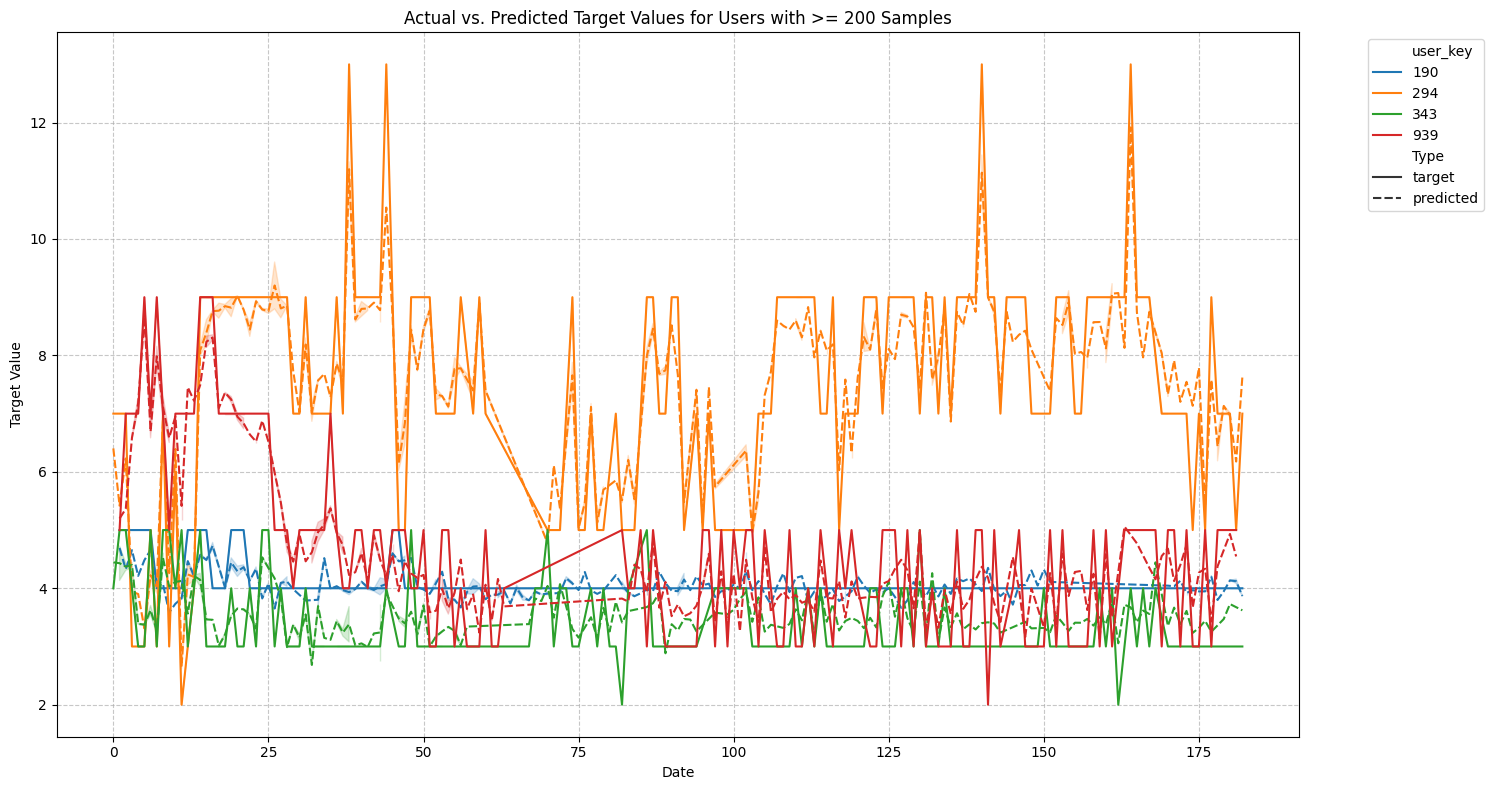

In [52]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=plot_data_melted, x='date', y='Value', hue='user_key', style='Type', palette='tab10', markers=False)
plt.title('Actual vs. Predicted Target Values for Users with >= 200 Samples')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

For users with three and six months of historical data, our personalized model was able to explain approximately 45% and 70% of the symptom variability, respectively. This significantly outperformed population-wide modeling approaches. We observed that only four users had more than 200 days of data. Among these four, some users exhibited very stable symptom patterns, while others experienced high volatility. Nevertheless, the accompanying graph illustrates that even for users with highly volatile symptoms, such as user 294, the model successfully captured the general trends.